In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

csv_path = "../../data/dataset_selection.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants — supprimés.")
df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

In [2]:
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad); x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [3]:
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)
test_df, val_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row["y"])

train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)
test_ds  = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621


In [4]:
# -------------------------
# EfficientNetV2-M
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Paramètres : {total_params:.1f}M")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)

Device: cuda
Paramètres : 52.9M


In [5]:
def evaluate(model, loader):
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            running_loss += criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

In [6]:
best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200
best_model_path = "efficientnetv2m.pth"

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)
    scheduler.step(va_acc)
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | lr {lr:.2e}")
    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping à l'epoch {epoch}")
        break

print(f"\nMeilleure val acc : {best_val_acc:.4f}")

Epoch 01 | train 0.8770/0.6929 | val 0.7034/0.8084 | lr 1.00e-04
Epoch 02 | train 0.6913/0.8029 | val 0.6568/0.8148 | lr 1.00e-04
Epoch 03 | train 0.6300/0.8405 | val 0.6313/0.8374 | lr 1.00e-04
Epoch 04 | train 0.5963/0.8639 | val 0.5987/0.8390 | lr 1.00e-04
Epoch 05 | train 0.5671/0.8772 | val 0.6144/0.8486 | lr 1.00e-04
Epoch 06 | train 0.5300/0.8987 | val 0.6333/0.8390 | lr 1.00e-04
Epoch 07 | train 0.5087/0.9108 | val 0.6184/0.8551 | lr 1.00e-04
Epoch 08 | train 0.4870/0.9285 | val 0.6470/0.8213 | lr 1.00e-04
Epoch 09 | train 0.4695/0.9380 | val 0.6407/0.8454 | lr 1.00e-04
Epoch 10 | train 0.4439/0.9515 | val 0.6390/0.8438 | lr 1.00e-04
Epoch 11 | train 0.4441/0.9539 | val 0.6608/0.8519 | lr 5.00e-05
Epoch 12 | train 0.4110/0.9702 | val 0.6661/0.8422 | lr 5.00e-05
Epoch 13 | train 0.3892/0.9819 | val 0.6414/0.8631 | lr 5.00e-05
Epoch 14 | train 0.3841/0.9835 | val 0.6306/0.8712 | lr 5.00e-05
Epoch 15 | train 0.3971/0.9791 | val 0.6745/0.8502 | lr 5.00e-05
Epoch 16 | train 0.3836/0

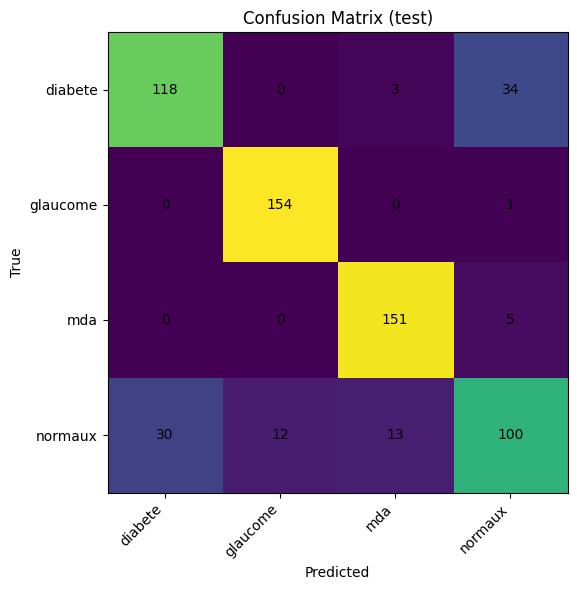

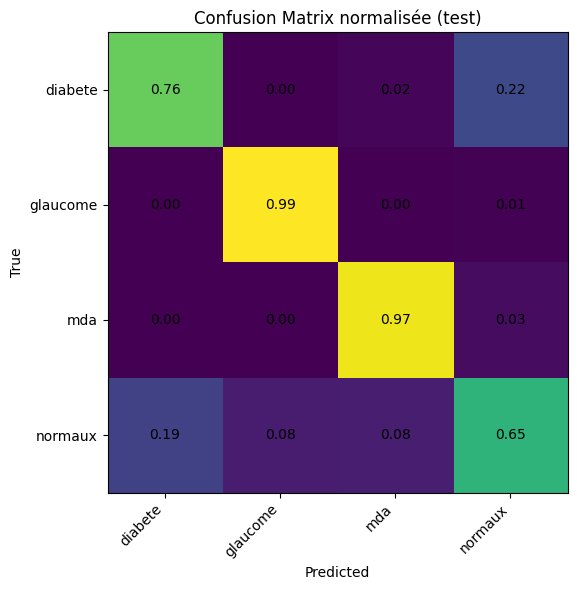


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.7973    0.7613    0.7789       155
    glaucome     0.9277    0.9935    0.9595       155
         mda     0.9042    0.9679    0.9350       156
     normaux     0.7143    0.6452    0.6780       155

    accuracy                         0.8422       621
   macro avg     0.8359    0.8420    0.8378       621
weighted avg     0.8360    0.8422    0.8380       621

AUC-ROC macro (OvR) : 0.9520

--- Comparatif ---
EfficientNet-B3 original  : 91.47%
DenseNet / ConvNeXt       : 93.40%
EfficientNetV2-S          : 84.22%


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))

def predict_on_loader(model, loader):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            probs = torch.softmax(model(x), dim=1)
            y_pred.append(probs.argmax(1).cpu().numpy())
            y_true.append(y.numpy())
            y_proba.append(probs.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)
    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else str(cm[i,j]), ha="center", va="center")
    plt.tight_layout(); plt.show()

y_true, y_pred, y_proba = predict_on_loader(model, test_loader)
cm = confusion_matrix(y_true, y_pred)

plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix (test)")
plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix normalisée (test)", normalize=True)

print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

try:
    auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"AUC-ROC macro (OvR) : {auc:.4f}")
except Exception as e:
    print(f"AUC-ROC : {e}")

print("\n--- Comparatif ---")
print("EfficientNet-B3 original  : 91.47%")
print("DenseNet / ConvNeXt       : 93.40%")
print(f"EfficientNetV2-S          : {(y_true == y_pred).mean()*100:.2f}%")

Nombre d'images mal classées : 98


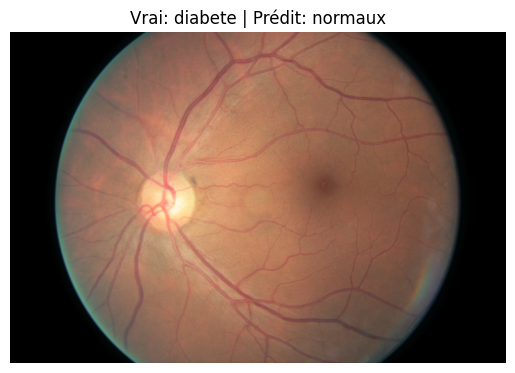

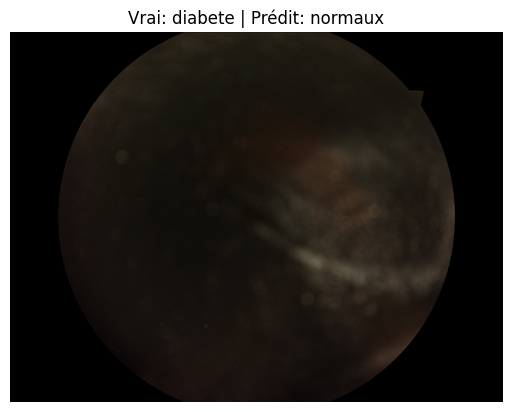

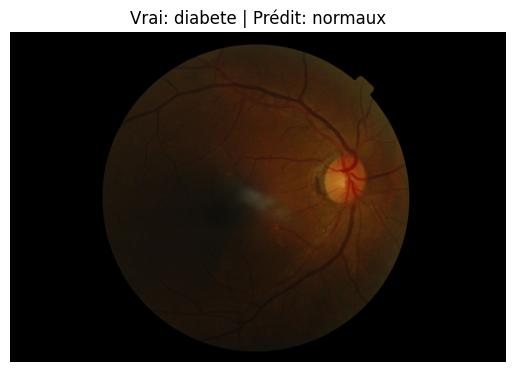

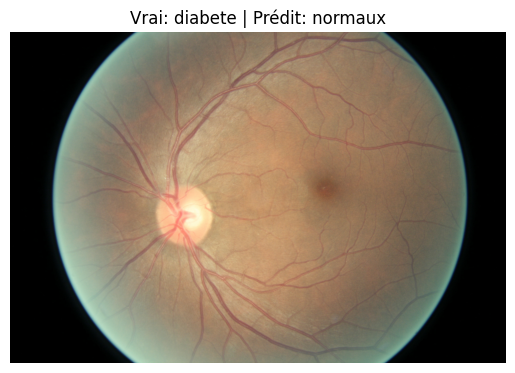

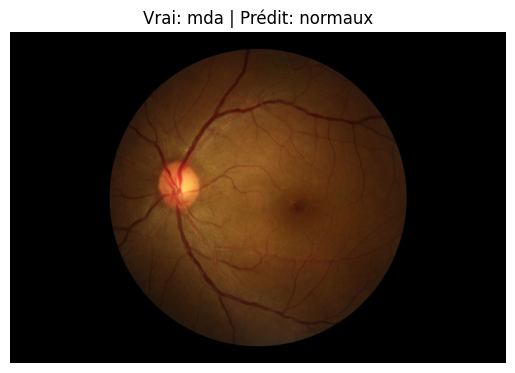

In [8]:
df_test = test_df.reset_index(drop=True)
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]['path']
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}")
    plt.axis("off")
    plt.show()